This notebook is intended to produce JPG files to be used in fiftyone.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
import rasterio as rio 
import numpy as np
import matplotlib.pyplot as plt
import cv2

def estimate_vmin_vmax(cam, percentiles=[5, 95]):
    """
    Estimates vmin and vmax values for the heatmap.

    Parameters:
    - cam (numpy.ndarray): The heatmap.

    Returns:
    - tuple: A tuple containing the vmin and vmax values.
    """
    vmin = np.percentile(cam, percentiles[0])
    vmax = np.percentile(cam, percentiles[1])
    return vmin, vmax

# Required by loader
def read_tif(file_path, band_indices):
    """
    Reads specified bands from a TIFF file.

    Parameters:
    - file_path (str): Path to the .tif file.
    - band_indices (list of int): Indices of the bands to read.

    Returns:
    - numpy.ndarray: A numpy array containing the stacked band data.
    """
    data = []
    with rio.open(file_path) as src:
        for index in band_indices:
            data.append(src.read(index))
    stacked_data = np.stack(data, axis=0)
    return np.transpose(stacked_data, (1, 2, 0))

DATA_PATH_VEN = '/Data_large/marine/Datasets/VENuS/ds_L0/perfect'
DATA_PATH_SEN = '/Data_large/marine/Datasets/VDS2Raw/imgs'

TIFF_VEN = list(Path(DATA_PATH_VEN).rglob('*.tif'))
TIFF_SEN = list(Path(DATA_PATH_SEN).rglob('*.tif'))

AUX FUNCTION

In [3]:
def plot_with_histograms(img):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=220)
    
    # Plot the image on the left
    axes[0].imshow(img)
    axes[0].set_title('Image')
    
    # Plot the histograms on the right
    axes[1].hist(img[:, :, 0].ravel(), bins=256, color='red', alpha=0.5, label='Red')
    axes[1].hist(img[:, :, 1].ravel(), bins=256, color='green', alpha=0.5, label='Green')
    axes[1].hist(img[:, :, 2].ravel(), bins=256, color='blue', alpha=0.5, label='Blue')
    axes[1].set_title('Histograms')
    axes[1].legend()
    
    plt.show()

SENTINEL

In [ ]:
for imgNumber in range(0, len(TIFF_SEN)):
    img = read_tif(TIFF_SEN[imgNumber], [3,2,1]) # Sequence selected for plt.imshow
    # plot_with_histograms(img / img.max())
    img = np.clip(img, 0, 1500)
    K = 2
    img = (img - img.mean()) / (K * img.std())
    img = np.clip(img, img.mean() - img.std(), img.mean() + 2 * img.std())
    img = (img - img.min()) / (img.max() - img.min())

    base = '/Data_large/marine/PythonProjects/MMDET/data/interpretation/sentinel'
    # Save img as an image file
    img = img * 255
    cv2.imwrite(f'{base}/{TIFF_SEN[imgNumber].stem}.jpg', img[:, :, ::-1])
    
plot_with_histograms(img)

VENUS

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


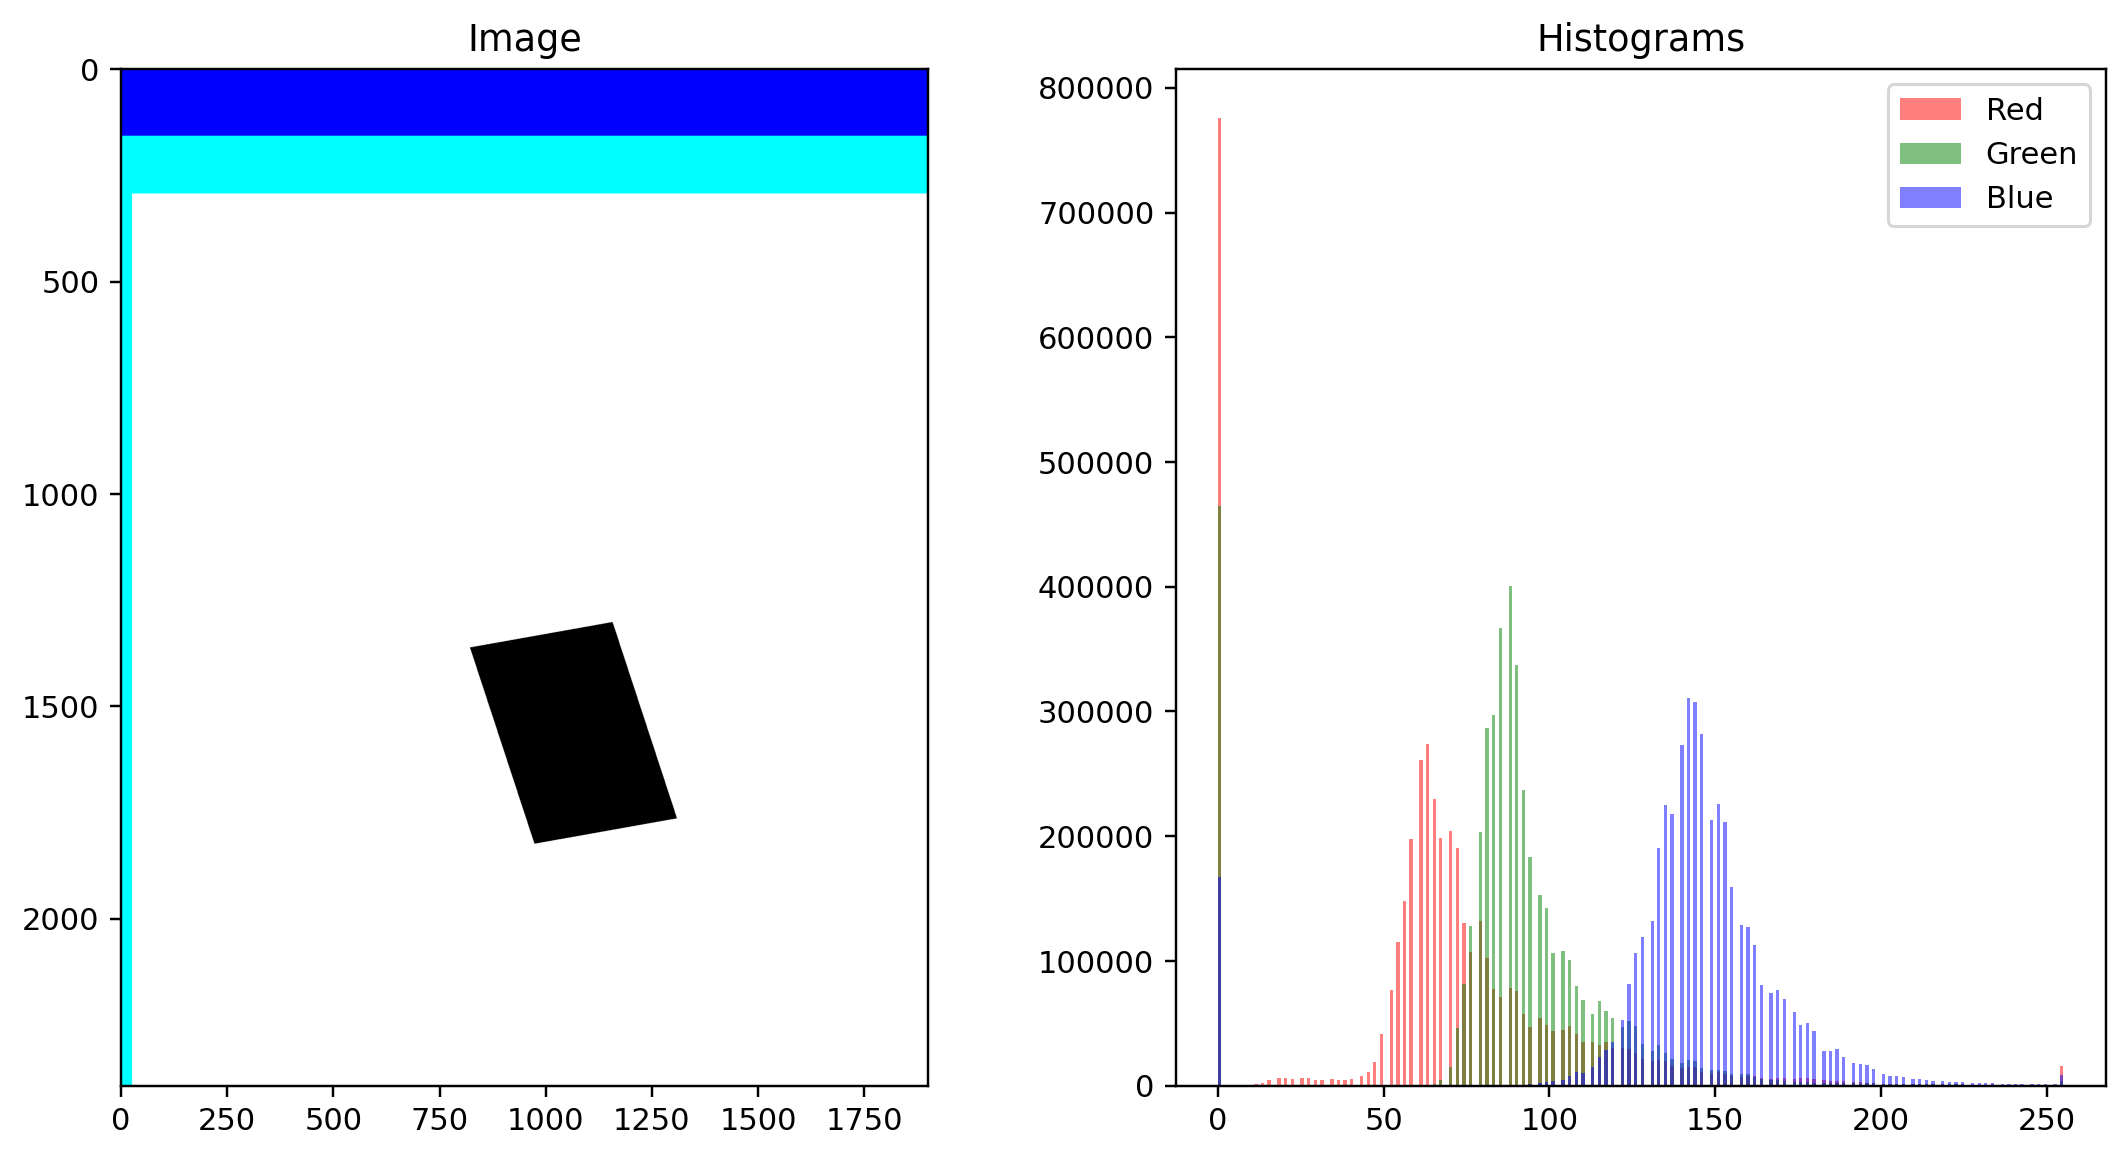

In [4]:
for imgNumber in range(0, len(TIFF_VEN)):
    img = read_tif(TIFF_VEN[imgNumber], [3,2,1]) # Sequence selected for plt.imshow
    # plot_with_histograms(img / img.max())
    img = np.clip(img, 0, 1500)
    K = 2
    img = (img - img.mean()) / (K * img.std())
    img = np.clip(img, img.mean() - img.std(), img.mean() + 2 * img.std())
    img = (img - img.min()) / (img.max() - img.min())

    base = '/Data_large/marine/PythonProjects/MMDET/data/interpretation/venus'
    # Save img as an image file
    img = img * 255
    cv2.imwrite(f'{base}/{TIFF_VEN[imgNumber].stem}.jpg', img[:, :, ::-1])
    
plot_with_histograms(img)

# COLOR SPACE TEST

In [ ]:
def histogram_equalization(img):
    """
    Performs histogram equalization on a grayscale image and normalizes the output to the range [0, 1].

    Parameters:
    - img (numpy.ndarray): A 2D numpy array representing the grayscale image.

    Returns:
    - numpy.ndarray: The histogram-equalized image with pixel values in the range [0, 1].
    """
    # Flatten the image array and calculate the histogram
    histogram, bins = np.histogram(img.flatten(), bins=256, range=[0, 256])

    # Calculate the cumulative distribution function (CDF)
    cdf = histogram.cumsum()
    cdf_normalized = cdf / cdf[-1]  # Normalize CDF to the range [0, 1]

    # Use linear interpolation to map the original image values to the equalized values
    img_equalized = np.interp(img.flatten(), bins[:-1], cdf_normalized)

    # Reshape the flat image back to its original shape
    img_equalized = img_equalized.reshape(img.shape)

    return img_equalized


def bgr_to_lab(bgr_image: np.ndarray) -> np.ndarray:
    """
    Converts an image from BGR color space to Lab color space.

    Parameters:
    bgr_image (np.ndarray): A NumPy array of shape (height, width, 3) representing the input image in BGR color space.
    
    Returns:
    np.ndarray: A NumPy array of shape (height, width, 3) representing the image in Lab color space.
    """
    # Ensure the image is in the proper range
    bgr_image = bgr_image.astype(np.float32) / 255.0

    # Convert BGR to XYZ color space
    # The transformation matrix for BGR to XYZ conversion
    BGR_to_XYZ = np.array([[0.412453, 0.357580, 0.180423],
                           [0.212671, 0.715160, 0.072169],
                           [0.019334, 0.119193, 0.950227]])

    # Extract B, G, R channels
    B, G, R = bgr_image[..., 0], bgr_image[..., 1], bgr_image[..., 2]

    # Matrix multiplication
    X = BGR_to_XYZ[0, 0] * R + BGR_to_XYZ[0, 1] * G + BGR_to_XYZ[0, 2] * B
    Y = BGR_to_XYZ[1, 0] * R + BGR_to_XYZ[1, 1] * G + BGR_to_XYZ[1, 2] * B
    Z = BGR_to_XYZ[2, 0] * R + BGR_to_XYZ[2, 1] * G + BGR_to_XYZ[2, 2] * B

    # Normalize for D65 white point
    X /= 0.950456
    Z /= 1.088754

    # Convert XYZ to Lab
    def f(t):
        delta = 6 / 29
        return np.where(t > delta**3, t ** (1/3), (t / (3 * delta**2)) + 4 / 29)

    L = 116 * f(Y) - 16
    a = 500 * (f(X) - f(Y))
    b = 200 * (f(Y) - f(Z))

    # Stack and return the Lab image
    lab_image = np.stack([L, a, b], axis=-1)
    
    return lab_image


def normalize_img(img, K=2):
    """
    Normalizes the image to the range [0, 1].

    For grayscale images, histogram equalization is applied. For color images,
    histogram equalization is applied to the luminance channel in the Lab color space
    to preserve color balance.

    Parameters:
    - img (numpy.ndarray): The image to be normalized. It can be a 2D (grayscale) or 3D (color) array.
    - K (float): A scaling factor for the standard deviation used in normalization (not used in this implementation).

    Returns:
    - numpy.ndarray: The normalized image with values clipped to the range [0, 1].
    """
    if img.ndim == 3 and img.shape[2] > 1:
        # Convert to 8-bit if the image is 16-bit
        if img.dtype == np.uint16:
            img = (img).astype(np.uint16)
        
        # Convert the image from BGR to Lab color space
        lab_img = bgr_to_lab(img)
        
        # Split the Lab image into its three channels
        l_channel, a_channel, b_channel = cv2.split(lab_img)
        
        # Apply histogram equalization to the L (lightness) channel
        l_channel_eq = histogram_equalization(l_channel)
        
        # Merge the channels back together
        lab_img_eq = np.stack((l_channel_eq, a_channel, b_channel), axis=-1)
        
        # Convert the image back to BGR color space
        img_eq = lab_to_bgr(lab_img_eq)
        
        # Normalize the image to the range [0, 1]
        normalized_img = img_eq.astype(np.float32) / 255.0
    else:
        # For a single-channel image or grayscale
        if img.dtype == np.uint16:
            img = img.astype(np.float32) / 65535.0
        elif img.dtype == np.uint8:
            img = img.astype(np.float32) / 255.0
        
        normalized_img = histogram_equalization(img)
    
    # Clip the values to be within the range [0, 1]
    return np.clip(normalized_img, 0, 1)


def lab_to_bgr(lab_image: np.ndarray) -> np.ndarray:
    """
    Converts an image from Lab color space to BGR color space.

    Parameters:
    lab_image (np.ndarray): A NumPy array of shape (height, width, 3) representing the input image in Lab color space.

    Returns:
    np.ndarray: A NumPy array of shape (height, width, 3) representing the image in BGR color space.
    """
    # Extract L, a, b channels
    L, a, b = lab_image[..., 0], lab_image[..., 1], lab_image[..., 2]

    # Convert Lab to XYZ
    def f_inv(t):
        delta = 6 / 29
        return np.where(t > delta, t ** 3, 3 * delta**2 * (t - 4 / 29))

    # Calculate Y, X, Z
    Y = f_inv((L + 16) / 116)
    X = f_inv((L + 16) / 116 + a / 500)
    Z = f_inv((L + 16) / 116 - b / 200)

    # De-normalize for D65 white point
    X *= 0.950456
    Z *= 1.088754

    # Convert XYZ to BGR
    # The transformation matrix for XYZ to BGR conversion
    XYZ_to_BGR = np.array([[3.240479, -1.537150, -0.498535],
                           [-0.969256, 1.875992, 0.041556],
                           [0.055648, -0.204043, 1.057311]])

    # Matrix multiplication
    R = XYZ_to_BGR[0, 0] * X + XYZ_to_BGR[0, 1] * Y + XYZ_to_BGR[0, 2] * Z
    G = XYZ_to_BGR[1, 0] * X + XYZ_to_BGR[1, 1] * Y + XYZ_to_BGR[1, 2] * Z
    B = XYZ_to_BGR[2, 0] * X + XYZ_to_BGR[2, 1] * Y + XYZ_to_BGR[2, 2] * Z

    # Clip the values to stay within valid range [0, 1] and convert to 8-bit image
    bgr_image = np.stack([B, G, R], axis=-1)
    return bgr_image

In [ ]:
# for imgNumber in range(0, len(TIFF_VEN)):
#     img = read_tif(TIFF_VEN[imgNumber], [7,4,3]) # Sequence selected for plt.imshow

#     img = normalize_img(img, channel_wise=True)
#     img = np.clip(img, 0, 1)
#     img *= 255
#     img = img.astype(np.uint8)


#     base = '/Data_large/marine/PythonProjects/MMDET/data/interpretation/venus'
#     # Save img as an image file
#     cv2.imwrite(f'{base}/{TIFF_VEN[imgNumber].stem}.jpg', img[:, :, ::-1])

In [ ]:
# for imgNumber in range(0, len(TIFF_SEN)):
#     img = read_tif(TIFF_SEN[imgNumber], [3,2,1]) # Sequence selected for plt.imshow

#     img = normalize_img(img, channel_wise=True, K = 0.01)
#     img = np.clip(img, 0, 1)
#     img *= 255
#     img = img.astype(np.uint8)
#     if imgNumber == 0:
#         break
#     base = '/Data_large/marine/PythonProjects/MMDET/data/interpretation/sentinel'
#     # Save img as an image file
#     cv2.imwrite(f'{base}/{TIFF_SEN[imgNumber].stem}.jpg', img[:, :, ::-1])
    
    
# plot_with_histograms(img)

In [ ]:
for imgNumber in range(0, len(TIFF_SEN)):
    img = read_tif(TIFF_SEN[imgNumber], [3,2,1]) # Sequence selected for plt.imshow
    # plot_with_histograms(img / img.max())
    img = np.clip(img, 0, 1500)
    K = 2
    img = (img - img.mean()) / (K * img.std())
    img = np.clip(img, img.mean() - img.std(), img.mean() + 2 * img.std())
    img = (img - img.min()) / (img.max() - img.min())

    base = '/Data_large/marine/PythonProjects/MMDET/data/interpretation/sentinel'
    # Save img as an image file
    img = img * 255
    cv2.imwrite(f'{base}/{TIFF_SEN[imgNumber].stem}.jpg', img[:, :, ::-1])
    
plot_with_histograms(img)

In [ ]:
def my_HE(img):
    # Convert the image from BGR to Lab color space
    lab_img = bgr_to_lab(img)

    reverted = lab_to_bgr(lab_img)
    # Split the Lab image into its three channels
    l_channel, a_channel, b_channel = cv2.split(lab_img)


    # 1. Histogram Clipping:
    l_channel_clipped = np.clip(l_channel, 0, 255)
    percentiles = [0, 99]
    vmin, vmax = estimate_vmin_vmax(l_channel, percentiles)
    l_channel_clipped = np.clip(l_channel, vmin, vmax)

    # 2. Histogram Equalization;
    l_channel_eq = l_channel_clipped
    histogram, bins = np.histogram(l_channel_eq.flatten(), bins=500, range=[vmin, vmax])
    cdf = histogram.cumsum()
    cdf_normalized = cdf / cdf[-1]  # Normalize CDF to the range [0, 1]
    img_equalized = np.interp(l_channel_eq.flatten(), bins[:-1], cdf_normalized)
    img_equalized = img_equalized * 255
    l_channel_eq = img_equalized.reshape(l_channel_eq.shape)
    

    # Merge the channels back together
    lab_img_eq = np.stack((l_channel_eq, a_channel, b_channel), axis=-1)
    # Convert the image back to BGR color space
    img_eq = lab_to_bgr(lab_img_eq)
    partial = img_eq
    partial = partial - partial.min()
    x = partial / partial.max()
    return x
    

In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=120)

# axes[0].imshow(l_channel_eq, cmap='jet')
# axes[0].set_title('Image')

# # Plot the histogram on the right
# axes[1].hist(l_channel_eq.flatten(), bins=256, color='blue', alpha=0.75)
# axes[1].set_title('Histogram')

# plt.show()

In [ ]:
imgNumber = 33

img = read_tif(TIFF_SEN[imgNumber], [3,2,1]) # Sequence selected for plt.imshow

plot_with_histograms(img / img.max())


tmp = my_HE(img)
gamma = 0.5
gammaC = np.power(tmp, gamma)

plot_with_histograms(gammaC)